In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_sessions = pd.read_csv("data/sessions.csv")
df_events = pd.read_csv("data/events.csv")

print(f"loaded {len(df_events)} events!")
display(df_events.head())

loaded 625 events!


,event_id,session_id,event_timestamp,event_type,viewed_category,android_error
0,019ede50-f52c-7161-b8e6-3a55486ec81b,019ede50f5187720aa7b0d9709ea9239,2023-01-01 16:42:45,view_item,Home Goods,NaN
1,019ede50-f52d-7af0-9ce7-3d7af8261289,019ede50f5187720aa7b0ddd0bed2637,2023-01-01 16:52:52,view_item,Apparel,NaN
2,019ede50-f52d-7af0-9ce7-3d823c311a2a,019ede50f5187720aa7b0ddd0bed2637,2023-01-01 16:53:39,add_to_cart,Apparel,NaN
3,019ede50-f527-7f41-ab52-68c00081cebb,019ede50f5187720aa7b03967edfc60f,2023-01-02 14:59:36,view_item,Consumables,NaN
4,019ede50-f527-7f41-ab52-68db2306048f,019ede50f5187720aa7b03aaa22e6803,2023-01-08 21:42:06,view_item,Electronics,NaN


In [4]:
funnel_counts = df_events['event_type'].value_counts()

print("Raw Event Counts:")
display(funnel_counts)

Raw Event Counts:


event_type
view_item         381
add_to_cart       120
begin_checkout     55
drop_off           54
purchase           15
Name: count, dtype: int64

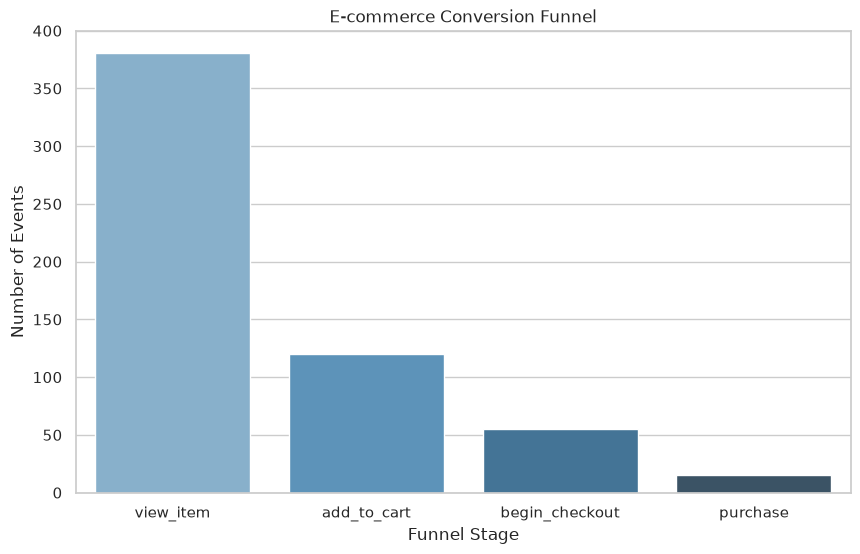

In [5]:
funnel_order = ["view_item", "add_to_cart", "begin_checkout", "purchase"]

ordered_funnel = funnel_counts.reindex(funnel_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=ordered_funnel.index, y=ordered_funnel.values, hue=ordered_funnel.index, palette="Blues_d", legend=False)
plt.title("E-commerce Conversion Funnel")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()

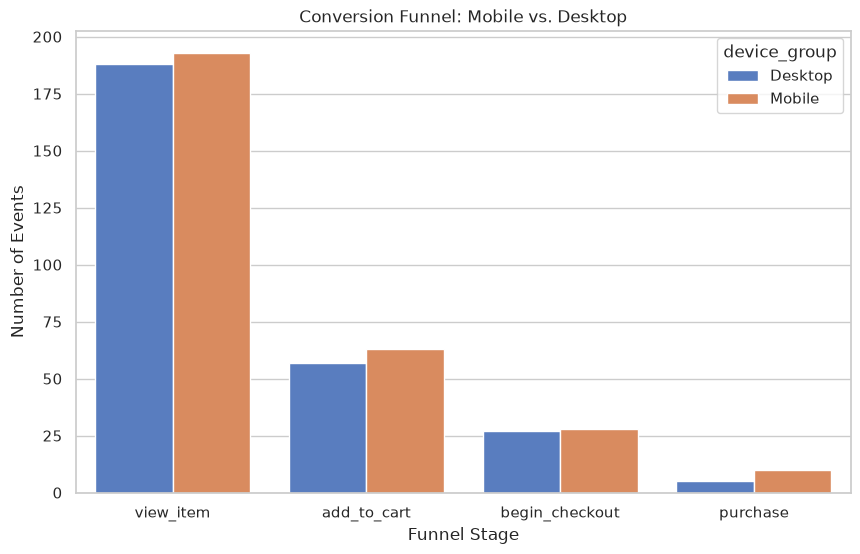

In [6]:
df_merged = df_events.merge(df_sessions[['session_id', 'device_group']], on='session_id', how='left')

device_funnel = df_merged.groupby(['device_group', 'event_type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=device_funnel, 
    x='event_type', 
    y='count', 
    hue='device_group', 
    order=funnel_order, 
    palette="muted"
)
plt.title("Conversion Funnel: Mobile vs. Desktop")
plt.ylabel("Number of Events")
plt.xlabel("Funnel Stage")
plt.show()

/tmp/ipykernel_118518/524534046.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


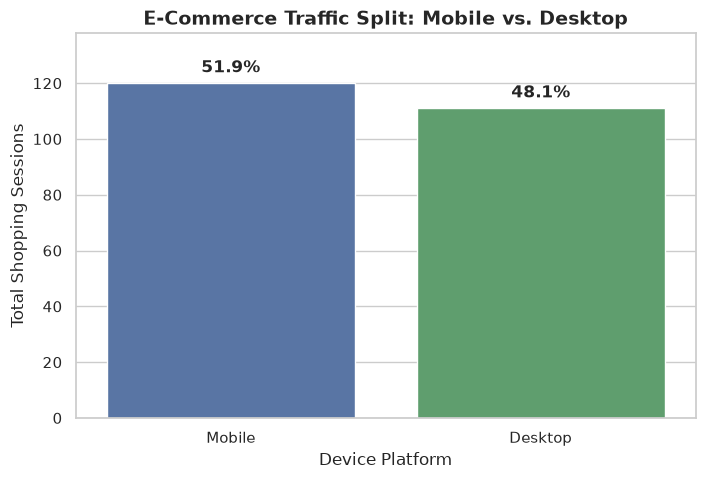

In [7]:
# Cell 5: Traffic Volume - Mobile vs. Desktop
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load sessions (if not already loaded in the current memory state)
df_sessions = pd.read_csv("data/sessions.csv")

# 1. Count the number of sessions per device group
device_traffic = df_sessions['device_group'].value_counts().reset_index()
device_traffic.columns = ['device_group', 'session_count']

# 2. Calculate percentages to make the chart more insightful
total_sessions = device_traffic['session_count'].sum()
device_traffic['percentage'] = (device_traffic['session_count'] / total_sessions) * 100

# 3. Draw a bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=device_traffic, 
    x='device_group', 
    y='session_count', 
    palette=['#4C72B0', '#55A868'] # Distinct colors for contrast
)

# 4. Add the percentage labels directly on top of the bars!
for i, p in enumerate(ax.patches):
    percentage_text = f"{device_traffic['percentage'].iloc[i]:.1f}%"
    ax.annotate(
        percentage_text, 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='bottom', fontsize=12, fontweight='bold', 
        xytext=(0, 5), textcoords='offset points'
    )

plt.title("E-Commerce Traffic Split: Mobile vs. Desktop", fontsize=14, fontweight='bold')
plt.ylabel("Total Shopping Sessions", fontsize=12)
plt.xlabel("Device Platform", fontsize=12)
plt.ylim(0, device_traffic['session_count'].max() * 1.15) # Add visual headroom for the labels
plt.show()